In [ ]:
#import packages
from __future__ import print_function
import tensorflow as tf
import keras
from tensorflow.keras import datasets, layers, models
import pandas as pd
import numpy as np
from keras.optimizers import Adam, SGD
# import warnings
# warnings.filterwarnings('ignore')
import cv2
from tensorflow.keras.utils import img_to_array, array_to_img, load_img, to_categorical
# from keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_lbl1 = pd.read_csv(r'/content/drive/MyDrive/pisc/d40.csv')

df_lbl1

,id_name,relation
0,1,2
1,2,1
2,3,2
3,4,2
4,5,2
...,...,...
39997,39998,1
39998,39999,1
39999,40000,1
40000,40001,1


In [ ]:
import zipfile
dn='/content/drive/MyDrive/pisc/allimgd40.npy.zip'
zip_ref = zipfile.ZipFile(dn, "r")
zip_ref.extractall('/content/drive/MyDrive/pisc/')
zip_ref.close()

In [ ]:
data_x = []
data_x=np.load('/content/drive/MyDrive/pisc/allimgd40.npy')

In [ ]:
data_y = []
for index, row in df_lbl1.iterrows():
  data_y.append(int(row['relation']))

In [ ]:
uniques, ids = np.unique(data_y, return_inverse=True)
labels1 = to_categorical(ids)
labels=ids
labels1

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]], dtype=float32)

In [ ]:
from sklearn.model_selection import train_test_split

#Splitting
X_train, X_test, y_train, y_test = train_test_split(data_x, labels1, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
print("Train: ", len(X_train), " Validation; ",len(X_val), " Test: ",len(X_test))

Train:  32001  Validation;  4000  Test:  4001


In [ ]:
print(X_train.shape)
print(y_train.shape)
input_shape = X_train[0].shape
print(input_shape)

(32001, 224, 224, 3)
(32001, 3)
(224, 224, 3)


In [ ]:
print(y_train.dtype)

float32


In [ ]:
y_train_l = np.argmax(y_train, axis=1)
ul = np.unique(y_train_l)
print(ul)

[0 1 2]


In [ ]:
y_val_l = np.argmax(y_val, axis=1)
ulv = np.unique(y_val_l)
print(ulv)

[0 1 2]


In [ ]:
y_test_l = np.argmax(y_test, axis=1)
ult = np.unique(y_test_l)
print(ult)

[0 1 2]


In [ ]:
# y1_train = y_train.astype(int)

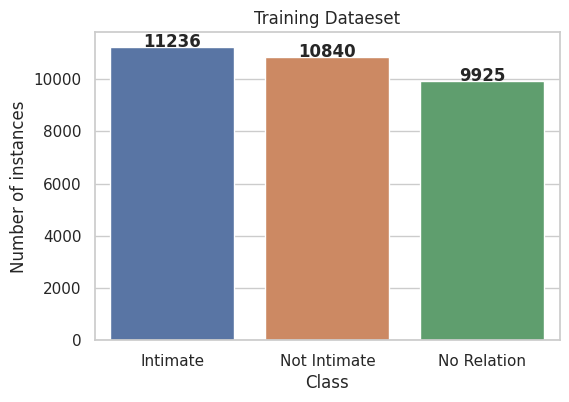

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['Intimate', 'Not Intimate', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_train_l:
    class_counts[label] += 1


sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
plt.title("Training Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts)
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")

for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

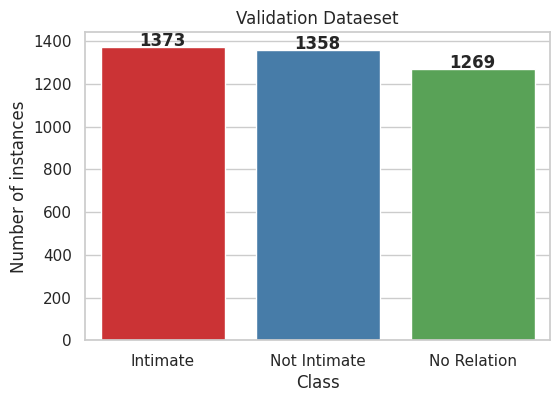

In [ ]:
# class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
class_names = ['Intimate', 'Not Intimate', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_val_l:
    class_counts[label] += 1



sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
plt.title("Validation Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts, palette= "Set1")
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")


for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

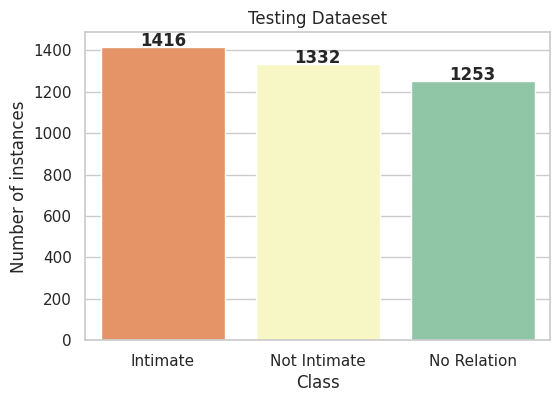

In [ ]:
# class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
class_names = ['Intimate', 'Not Intimate', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_test_l:
    class_counts[label] += 1


sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
plt.title("Testing Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts, palette= "Spectral")
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")

for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

In [ ]:
# train_filenames, testval_filenames = train_test_split(image_filenames, train_size=train_split, random_state=42)
#     val_filenames, test_filenames = train_test_split(testval_filenames, train_size=val_split/(train_split+val_split), random_state=42)

new

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the hyperparameters
num_classes = 3
image_size = 224
patch_size = 16
num_patches = (image_size // patch_size) ** 2
embedding_dim = 128
num_heads = 8
mlp_dim = 256
dropout_rate = 0.1 #0.5
batch_size = 32
epochs = 50
learning_rate = 0.0001

inputs = keras.Input(shape=(image_size, image_size, 3))

# Convolutional layers
x = layers.Conv2D(128, kernel_size=3, strides=2, padding="same", kernel_regularizer=keras.regularizers.l2(0.001))(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(256, kernel_size=3, strides=2, padding="same", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(512, kernel_size=3, strides=2, padding="same", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(1024, kernel_size=3, strides=2, padding="same", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(2048, kernel_size=3, strides=2, padding="same", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

# CVT layers
x = layers.Reshape((num_patches, -1))(x)
x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, dropout=dropout_rate)(x, x)
x = layers.Dropout(dropout_rate)(x)
x = layers.LayerNormalization()(x)

x = layers.Dense(mlp_dim, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(embedding_dim)(x)

# Classification head
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

# # Use transfer learning
base_model = keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(image_size, image_size, 3))

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

modelb1 = keras.Model(inputs=base_model.input, outputs=outputs)


modelb1.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
modelb1.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [ ]:
history = modelb1.fit(X_train, y_train, epochs=100,
                    validation_data=(X_val, y_val))

Epoch 1/100
1001/1001 [==============================] - 125s 71ms/step - loss: 0.6882 - accuracy: 0.7092 - val_loss: 0.9917 - val_accuracy: 0.5882
Epoch 2/100
1001/1001 [==============================] - 66s 66ms/step - loss: 0.3653 - accuracy: 0.8615 - val_loss: 0.5615 - val_accuracy: 0.7855
Epoch 3/100
1001/1001 [==============================] - 64s 64ms/step - loss: 0.1987 - accuracy: 0.9267 - val_loss: 0.6199 - val_accuracy: 0.7985
Epoch 4/100
1001/1001 [==============================] - 64s 64ms/step - loss: 0.1401 - accuracy: 0.9487 - val_loss: 0.5621 - val_accuracy: 0.8170
Epoch 5/100
1001/1001 [==============================] - 65s 65ms/step - loss: 0.1183 - accuracy: 0.9573 - val_loss: 0.5406 - val_accuracy: 0.8365
Epoch 6/100
1001/1001 [==============================] - 65s 65ms/step - loss: 0.0917 - accuracy: 0.9677 - val_loss: 0.7271 - val_accuracy: 0.8142
Epoch 7/100
1001/1001 [==============================] - 66s 66ms/step - loss: 0.0874 - accuracy: 0.9695 - val_loss: 

In [ ]:
# modelb.save('pcvt.h5')

In [ ]:
modelb1.save('/content/drive/MyDrive/pisc/pcvtnc.h5')

In [ ]:
import pickle

with open('history.pickle', 'wb') as file_pi:
    pickle.dump(history.history, file_pi)

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/pisc/pcvtnc.h5')

In [ ]:
from sklearn.metrics import average_precision_score

# Use the model to make predictions on the test dataset
predicted_probs = model.predict(X_test)

# Calculate the average precision for each class
average_precision = average_precision_score(y_test, predicted_probs, average=None)

# Calculate the mean average precision
mean_average_precision = average_precision_score(y_test, predicted_probs, average='macro')

126/126 [==============================] - 4s 24ms/step


In [ ]:
print(mean_average_precision)

0.9024812447756249


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print('Test loss:', loss)
print('Test accuracy:', accuracy)

126/126 [==============================] - 4s 22ms/step - loss: 1.0483 - accuracy: 0.8120
Test loss: 1.0483452081680298
Test accuracy: 0.812047004699707


In [ ]:
y_pred = model.predict(X_test)
y_pred_labels = uniques[np.argmax(y_pred, axis=1)]
print(y_pred_labels)
y_test_labels = uniques[np.argmax(y_test, axis=1)]
print(y_pred_labels)
accuracy = np.mean(y_pred_labels == y_test_labels)
print('Test accuracy:', accuracy)

126/126 [==============================] - 2s 19ms/step
[1 1 3 ... 2 3 2]
[1 1 3 ... 2 3 2]
Test accuracy: 0.8120469882529368


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_labels, y_pred_labels)

print('Confusion matrix:')
print(cm)

Confusion matrix:
[[1270   57   89]
 [ 262  943  127]
 [ 177   40 1036]]


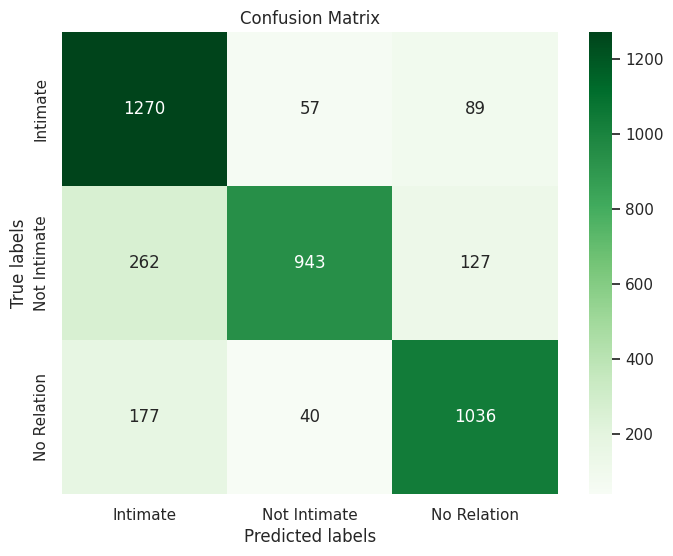

In [ ]:
class_names = class_names = ['Intimate', 'Not Intimate', 'No Relation']


cm = confusion_matrix(y_test_labels, y_pred_labels)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_df, fmt='d', annot=True, cmap='Greens', ax=ax)

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')

plt.show()

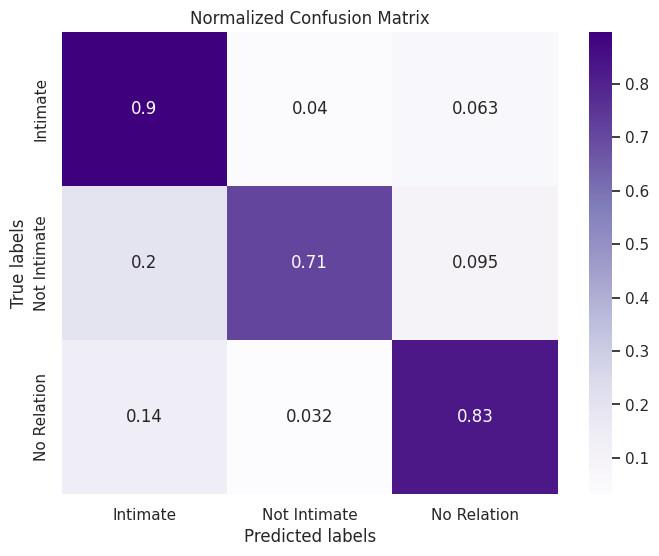

In [ ]:
class_names = ['Intimate', 'Not Intimate', 'No Relation']

cm = confusion_matrix(y_test_labels, y_pred_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

cm_norm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, cmap='Purples', ax=ax)

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Normalized Confusion Matrix')

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_labels, y_pred_labels, target_names=class_names))

              precision    recall  f1-score   support

    Intimate       0.74      0.90      0.81      1416
Not Intimate       0.91      0.71      0.80      1332
 No Relation       0.83      0.83      0.83      1253

    accuracy                           0.81      4001
   macro avg       0.83      0.81      0.81      4001
weighted avg       0.82      0.81      0.81      4001



In [ ]:
report = classification_report(y_test_labels, y_pred_labels, target_names=class_names, output_dict=True)

print("Weighted Average Precision: {:.2f}".format(report['weighted avg']['precision']))
print("Weighted Average Recall: {:.2f}".format(report['weighted avg']['recall']))
print("Weighted Average F1-score: {:.2f}".format(report['weighted avg']['f1-score']))
print("Weighted Average Support: {:.2f}".format(report['weighted avg']['support']))

Weighted Average Precision: 0.82
Weighted Average Recall: 0.81
Weighted Average F1-score: 0.81
Weighted Average Support: 4001.00


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test_labels, y_pred_labels, target_names=class_names, output_dict=True)

print('Overall Precision: {:.2f}'.format(report['macro avg']['precision']))
print('Overall Recall: {:.2f}'.format(report['macro avg']['recall']))
print('Overall F1-score: {:.2f}'.format(report['macro avg']['f1-score']))

Overall Precision: 0.83
Overall Recall: 0.81
Overall F1-score: 0.81
